# 게임 세계관 분석 실험

**파이프라인 흐름:**
1. 게임 텍스트 JSON 로드
2. 영어 텍스트 → Word Cloud 생성 (불용어 제거)
3. GPT로 세계관/어투 분석

**필요한 패키지:**
```bash
pip install wordcloud matplotlib openai pandas
```


In [1]:
# 패키지 설치 (첫 실행 시)
# !pip install wordcloud matplotlib openai pandas

In [2]:
import os
from pathlib import Path
import destiny2_analysis as d2

try:
    from dotenv import load_dotenv
    cwd = Path.cwd().resolve()
    project_root = cwd
    if not (project_root / 'destiny2_analysis.py').exists() and (project_root.parent / 'destiny2_analysis.py').exists():
        project_root = project_root.parent
    load_dotenv(project_root / '.env', override=True)
except Exception:
    pass

# ⚠️ OpenAI API 키를 여기에 입력하세요
API_KEY = os.getenv('OPENAI_API_KEY')
if not API_KEY:
    raise ValueError('OPENAI_API_KEY를 프로젝트 루트(.env)에 설정해주세요.')

# 분석할 JSON 파일 경로
DATA_PATH = "destiny2_translation.json"

## Step 1. 데이터 로드

In [3]:
data = d2.load_data(DATA_PATH)

# 데이터 구조 확인
from collections import Counter
import pandas as pd

type_counts = Counter(d["type"] for d in data)
domain_counts = Counter(d["domain"] for d in data)

print("타입별 개수:", dict(type_counts))
print("도메인별 개수:", dict(domain_counts))

# 샘플 5개 보기
pd.DataFrame(data[:5])[["id", "type", "domain", "en", "ko"]]

총 40609개 항목 로드 완료
타입별 개수: {'name': 23367, 'description': 13206, 'lore_description': 2483, 'lore_subtitle': 1499, 'lore_name': 54}
도메인별 개수: {'item': 22913, 'activity': 2967, 'perk': 3006, 'quest': 370, 'system': 7317, 'lore': 4036}


,id,type,domain,en,ko
0,0,name,item,Legendary Engram,전설 엔그램
1,1,description,item,An engram with complex markers. Contains a ran...,복잡한 표시가 있는 엔그램입니다. 무작위 전설 무기 또는 방어구가 들어 있습니다.
2,2,name,item,Spacewalk Cloak,우주 유영 망토
3,3,name,item,Tangled Web Helm,뒤엉킨 거미줄 투구
4,4,name,item,Raven Shard,까마귀 파편


## Step 2. Word Cloud 생성

- `description`, `lore_subtitle` 텍스트 사용
- 일반 영어 불용어 + 게임 UI 잡음어 제거 → 세계관 핵심 단어가 부각됩니다


In [4]:
# 텍스트 추출
wc_texts = d2.get_texts_by_type(
    data,
    types={"description", "lore_subtitle"},
)
print(f"대상 텍스트: {len(wc_texts)}개")

# 단어 추출 & 빈도 계산
words = d2.clean_text(wc_texts)
top_words = d2.get_top_words(words, n=30)

print("\n상위 30개 단어:")
for word, count in top_words:
    print(f"  {word:20s} {count}")

대상 텍스트: 14705개

상위 30개 단어:
  weapon               1762
  complete             1721
  defeat               1505
  damage               1468
  ornament             1159
  combatants           1126
  final                892
  targets              808
  blows                745
  armor                680
  appearance           646
  weapons              619
  change               576
  energy               568
  void                 562
  contains             529
  time                 519
  speed                514
  arc                  505
  solar                495
  difficulty           463
  defeating            460
  season               450
  fireteam             420
  full                 414
  ability              414
  guardians            412
  additional           407
  stasis               407
  lost                 402


c:\Users\LLOYDK\Desktop\Demo\LLM_Translation-pseudo_lab\destiny2_analysis.py:116: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\LLOYDK\Desktop\Demo\LLM_Translation-pseudo_lab\destiny2_analysis.py:116: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\LLOYDK\Desktop\Demo\LLM_Translation-pseudo_lab\destiny2_analysis.py:116: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\LLOYDK\Desktop\Demo\LLM_Translation-pseudo_lab\destiny2_analysis.py:116: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\LLOYDK\Desktop\Demo\LLM_Translation-pseudo_lab\destiny2_analysis.py:116: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\LLOYDK\Desktop\Demo\LLM_Translation-pseudo_lab\destin

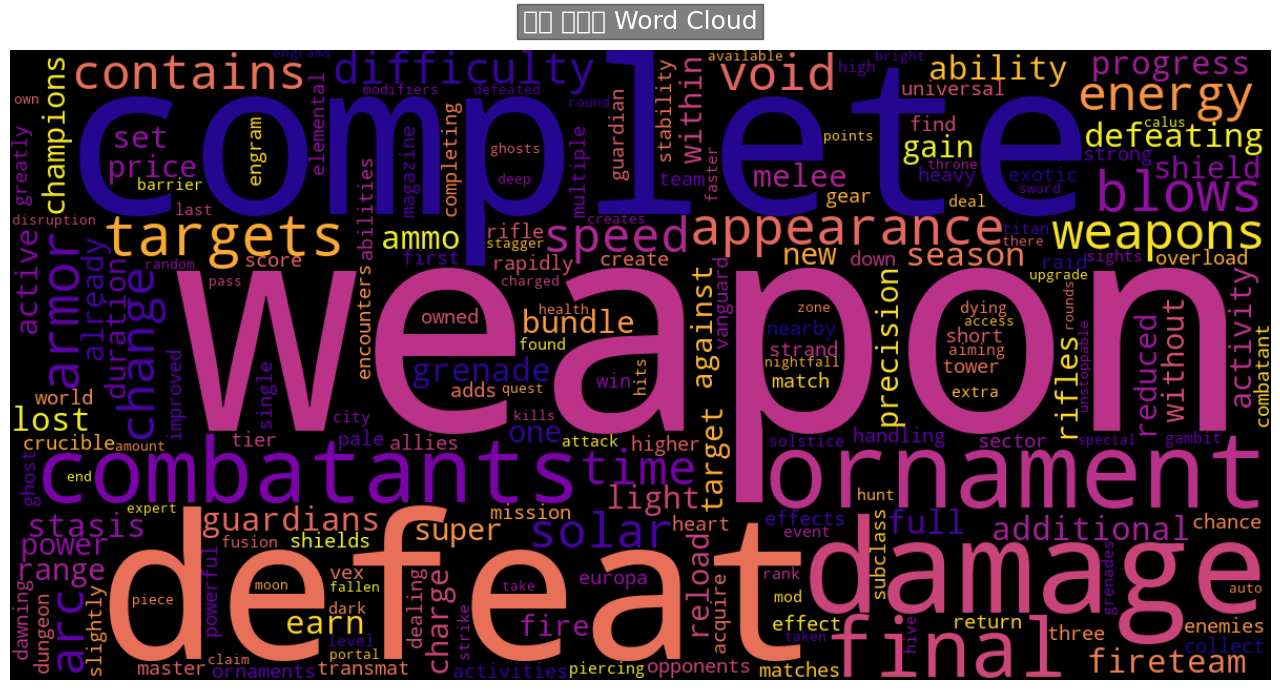

Word Cloud 저장: wordcloud_game.png


'wordcloud_game.png'

In [5]:
# Word Cloud 생성 및 저장
d2.make_wordcloud(words)

## Step 3. GPT로 세계관 / 어투 분석

- 상위 100개 단어 + 텍스트 샘플을 GPT에 전달
- 시대 배경, 어조, 핵심 테마를 도출합니다


In [6]:
# description 텍스트 샘플 확인 (lore_description 제외)
desc_only_texts = d2.get_texts_by_type(data, types={"description"})
desc_samples = sorted(desc_only_texts, key=len, reverse=True)[:3]

print(f"description 텍스트 수 {len(desc_only_texts)}개")
print("\n--- 가장 긴 description 샘플 미리보기 ---")
print(desc_samples[0][:500], "...")


description 텍스트 수 13206개

--- 가장 긴 description 샘플 미리보기 ---
• Earn Medallions from completing Contender or Platinum Cards (acquired from Eva) or ritual activities with your class item equipped. Medallions can be banked at the podium in the Tower for event rewards, and they will contribute toward your class standing! • Acquire Diamond Contender Cards from Eva in order to earn incredibly lucrative Diamond Medallions! • Achieving high scores in the "Vying for Supremacy" or "Shoot to Score" quests will allow you to light torches and unlock Tower chests. Towe ...


In [7]:
# GPT 세계관 분석 실행
top_words_100 = d2.get_top_words(words, n=100)
analysis = d2.analyze_worldview_with_gpt(top_words_100, desc_samples, API_KEY)

from IPython.display import Markdown
Markdown(analysis)

1. **시대 배경 및 세계관**  
   이 게임은 SF 및 판타지 요소가 혼합된 세계관을 가지고 있습니다. "Guardians," "Traveler," "energy," "void," "combatants"와 같은 용어는 초자연적이고 우주적인 힘을 다루는 설정을 암시합니다. "Lost Sector"와 같은 표현은 탐험과 전투가 중요한 요소로 작용하는 포스트아포칼립스적인 환경을 나타내며, 플레이어가 다양한 적들과 싸우고 보상을 얻는 구조를 통해 경쟁적인 요소가 강조됩니다.

2. **서술 어조 및 분위기**  
   내러티브의 톤은 전투적이고 경쟁적인 분위기를 띠고 있습니다. "defeating," "final blow," "boost of energy"와 같은 단어들은 긴장감과 역동성을 느끼게 하며, 플레이어가 목표를 달성하기 위해 끊임없이 도전해야 하는 상황을 강조합니다. 또한, "blessings," "gear," "rewards"와 같은 표현은 긍정적인 보상 체계를 통해 플레이어의 성취감을 높이는 요소로 작용합니다.

3. **핵심 테마**  
   반복적으로 등장하는 주제는 "전투와 경쟁"입니다. 플레이어는 적을 처치하고 점수를 얻는 과정에서 자신의 능력을 시험하며, "energy"와 "power"라는 개념은 이러한 경쟁에서 중요한 역할을 합니다. 또한, "blessings"와 같은 요소는 플레이어가 성취를 통해 얻는 보상을 강조하며, 전반적으로 승리와 성취의 테마가 두드러집니다.

4. **문체 특징**  
   문장 구조는 간결하고 명확하며, 주로 짧은 문장과 리스트 형식으로 정보가 전달됩니다. 이는 게임의 빠른 진행과 이해를 돕기 위한 것으로 보입니다. 또한, 명령형과 설명형 문장이 혼합되어 있어 플레이어에게 직접적인 행동을 유도하는 방식이 특징적입니다. 전문 용어와 게임 내 고유 명사가 자주 사용되어 게임의 몰입감을 높입니다.

5. **한국어 번역 가이드라인**  
   - **경어 사용 여부**: 게임의 분위기와 대상에 따라 반말을 사용하되, 플레이어와 NPC 간의 대화에서는 존댓말을 적절히 혼합하여 사용합니다. 예를 들어, 플레이어가 NPC에게 말을 걸 때는 존댓말을, 게임 내 설명에서는 반말을 사용할 수 있습니다.
   - **어휘 선택 방향**: 게임의 전문성과 몰입감을 유지하기 위해 한자어와 순우리말을 조화롭게 사용합니다. 예를 들어, "전투"와 "보상" 같은 한자어를 사용하면서도 "빛"과 "어둠" 같은 순우리말을 적절히 섞어 사용합니다. 영어 직역은 피하고, 자연스러운 한국어 표현으로 변환합니다.
   - **어조 유지를 위한 팁**: 전투적이고 긴장감 있는 어조를 유지하기 위해, 강한 동사와 명령형 표현을 사용합니다. 예를 들어, "적을 처치하라!"와 같은 표현을 통해 플레이어의 행동을 유도하고, "보상을 획득하라!"와 같은 문구로 성취감을 강조합니다.

In [8]:
# 분석 결과 저장 (텍스트 + JSON)
from pathlib import Path
import json

# 1) 텍스트 파일 저장 (WORLDVIEW_CONTEXT로 바로 쓰기 좋음)
txt_path = Path("worldview_context.txt")
txt_path.write_text(analysis, encoding="utf-8")

# 2) JSON 저장 (기존 호환)
json_path = Path("game_analysis_results.json")
payload = {
    "worldview_analysis": analysis,
    "translation_samples": []
}
json_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")

print("saved txt :", txt_path.resolve())
print("saved json:", json_path.resolve())

saved txt : C:\Users\LLOYDK\Desktop\Demo\LLM_Translation-pseudo_lab\worldview_context.txt
saved json: C:\Users\LLOYDK\Desktop\Demo\LLM_Translation-pseudo_lab\game_analysis_results.json
